# Task 2 - Detection

## Import and setup

In [2]:
!pip install opencv-python numpy matplotlib open3d Pillow scipy sympy easydict torch pillow protobuf==3.20.0 shapely ipykernel ipywidgets open3d

In [2]:
import os

import cv2
from IPython.display import display
import numpy as np
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import open3d as o3d
from PIL import Image
from scipy.spatial.transform import Rotation
from sympy import Matrix
from easydict import EasyDict as edict
from typing import Tuple

import tools.dataset_tools as dataset_tools
from tools.frame_pb2 import Frame
import tools.plot_tools as plot_tools
import torch


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Process raw LiDAR point cloud data

In [3]:
frame = dataset_tools.read_frame("dataset/data_2/frame_0.pb")

# print number of lidars
print(f"Number of lidars: {len(frame.lidars)}")
lidar = frame.lidars[0]

# Extract pointcloud
pcl = dataset_tools.decode_lidar(lidar)
print(f"Pointcloud shape: {pcl.shape}")

Number of lidars: 1
Pointcloud shape: (196608, 4)


## Convert to Bird's Eye View representation

In [134]:
def visualize_bev(bev):
    """
    Visualize Bird's Eye View (BEV) data both as a combined map and individual channels
    
    Args:
        bev: numpy array of shape (channels, height, width)
    """
    # Create a figure with two rows
    plt.figure(figsize=(15, 10))
    
    # Plot combined BEV map
    plt.subplot(2, 1, 1)
    bev_map_display = np.transpose(bev, (1, 2, 0))
    plt.imshow(bev_map_display)
    plt.colorbar()
    plt.title("Combined Bird's Eye View Map")
    
    # Plot individual channels
    plt.subplot(2, 1, 2)
    titles = ['Density', 'Height', 'Intensity']
    for i, title in enumerate(titles):
        plt.subplot(2, 3, i + 4)  # Position in bottom row
        im = plt.imshow(bev_map_display[:,:,i])
        plt.title(title)
        plt.colorbar(im)
    
    # plt.tight_layout()
    plt.show()

In [149]:
config = edict()
config.lims = edict()
config.lims.x = [-75, 75]
config.lims.y = [-75, 75]
config.lims.z = [-2, 5]
config.lims.intensity = [0, 0.4]
config.bev_height = 608
config.bev_width = 608

BEV shape: (3, 608, 608)


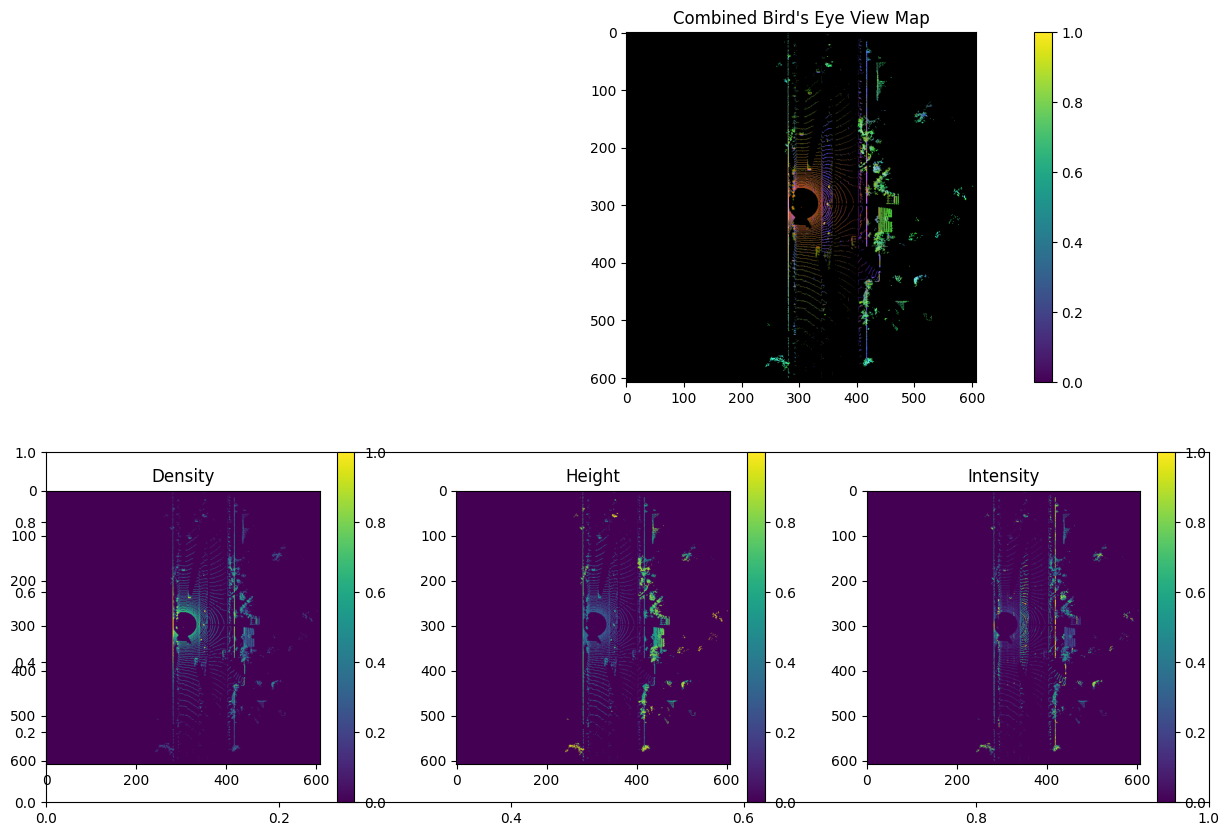

In [164]:
def pcl_to_bev(pcl: np.ndarray, configs: edict) -> np.ndarray:
    """SFA3D-style BEV map creation while maintaining compatibility with your config structure
    
    Args:
        pcl: pointcloud as numpy array [n_points, m_channels]
        configs: configuration parameters
    Returns:
        RGB_Map: BEV map as [3, height, width] array
    """
    # Create copy to avoid modifying original
    points = np.copy(pcl)
    
    # Filter points within detection range
    mask = np.where((points[:, 0] >= configs.lims.x[0]) & (points[:, 0] <= configs.lims.x[1]) &
                    (points[:, 1] >= configs.lims.y[0]) & (points[:, 1] <= configs.lims.y[1]) &
                    (points[:, 2] >= configs.lims.z[0]) & (points[:, 2] <= configs.lims.z[1]))
    points = points[mask]
    
    # Adjust height relative to ground (as in your implementation)
    points[:, 2] = points[:, 2] - configs.lims.z[0]
    
    height = configs.bev_height + 1
    width = configs.bev_width + 1
    
    # Calculate discretization (similar to your bev_x_discret and bev_y_discret)
    x_discretization = (configs.lims.x[1] - configs.lims.x[0]) / configs.bev_height
    y_discretization = (configs.lims.y[1] - configs.lims.y[0]) / configs.bev_width
    
    # Discretize Feature Map (SFA3D style)
    points[:, 0] = np.int_(np.floor((configs.lims.x[1] - points[:, 0]) / x_discretization))  # Inverted x-coordinate mapping
    points[:, 1] = np.int_(np.floor(points[:, 1] / y_discretization) + width / 2)

    
    # Sort points (SFA3D style)
    sorted_indices = np.lexsort((-points[:, 2], points[:, 1], points[:, 0]))
    points = points[sorted_indices]
    _, unique_indices, unique_counts = np.unique(points[:, 0:2], axis=0, return_index=True, return_counts=True)
    points_top = points[unique_indices]
    
    # Initialize maps
    heightMap = np.zeros((height, width))
    intensityMap = np.zeros((height, width))
    densityMap = np.zeros((height, width))
    
    # Fill maps (SFA3D style)
    max_height = float(np.abs(configs.lims.z[1] - configs.lims.z[0]))
    heightMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = points_top[:, 2] / max_height
    # Clip intensity values to reasonable range and normalize
    clipped_intensities = np.clip(points_top[:, 3], configs.lims.intensity[0], configs.lims.intensity[1])
    intensityMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = clipped_intensities / (configs.lims.intensity[0] + configs.lims.intensity[1])
    densityMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = np.minimum(1.0, np.log(unique_counts + 1) / np.log(64))


    
    # Create RGB Map (same channel ordering as SFA3D)
    bev = np.zeros((3, height - 1, width - 1))
    bev[0, :, :] = densityMap[:configs.bev_height, :configs.bev_width]  # r_map
    bev[1, :, :] = heightMap[:configs.bev_height, :configs.bev_width]   # g_map
    bev[2, :, :] = intensityMap[:configs.bev_height, :configs.bev_width]# b_map
    
    return bev

# Test the function
bev = pcl_to_bev(pcl, config)
print(f"BEV shape: {bev.shape}")

# Visualize BEV channels
visualize_bev(bev)

## Create Dataset

In [152]:
class LidarDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir: str):
        """
        Initialize the dataset
        Args:
            data_dir: path to dataset directory containing frame_*.pb files
            config: configuration dictionary with BEV parameters
        """
        self.data_dir = data_dir
        
        # Get list of all frame files
        self.frame_files = []
        for file in sorted(os.listdir(data_dir)):
            if file.startswith('frame_') and file.endswith('.pb'):
                self.frame_files.append(os.path.join(data_dir, file))
                
        print(f"Found {len(self.frame_files)} frames")
        
    def __len__(self):
        return len(self.frame_files)
    
    def __getitem__(self, idx):
        """
        Get a single frame data
        Args:
            idx: frame index
        Returns:
            pointcloud: (N, 4) array of points (x,y,z,intensity)
        """
        # Read frame
        frame = dataset_tools.read_frame(self.frame_files[idx])
        
        # Get first lidar's pointcloud
        lidar = frame.lidars[0]
        pointcloud = dataset_tools.decode_lidar(lidar)
        detections = lidar.detections
        bev = pcl_to_bev(pointcloud, config)
        
        # Convert numpy array to pytorch tensor
        bev = torch.from_numpy(bev).float()
        
        return bev, detections

# Create dataset
dataset = LidarDataset("dataset/data_2")

# Test loading first frame
bev, detections = dataset[0]
print(f"Loaded pointcloud shape: {bev.shape}")
print(f"Loaded {len(detections)} number of detections")
print(f"Detection 0: {detections[0]}")


Found 199 frames
Loaded pointcloud shape: torch.Size([3, 608, 608])
Loaded 6 number of detections
Detection 0: id: "8EFRSwEXBf9P-SzIDRzx0A"
pos: -20.02004
pos: 7.2557716
pos: 0.50248885
rot: 0.0
rot: 0.0
rot: -0.009081202
scale: 4.7602353
scale: 1.9828961
scale: 1.68



## Feed into deep learning model to detect vehicles

### Define Model

In [153]:
from SFA3D.sfa.models.model_utils import create_model

# from the demo config of SFA3D

model_config = edict({
    "saved_fn": "fpn_resnet_18", # the name using for saving logs, models,...
    "arch": "fpn_resnet_18", # The name of the model architecture
    "pretrained_path": "SFA3D/checkpoints/fpn_resnet_18/fpn_resnet_18_epoch_300.pth",
    "K": 50, # the number of top K
    "no_cuda": False, #If true, cuda is not used.
    "gpu_idx": 0, #The index of the GPU to use.
    "num_samples": None,
    "num_workers": 1,
    "batch_size": 1,
    "peak_thresh": 0.2,
    "save_test_output": False,
    "output_format": "image",
    "output_video_fn": "out_fpn_resnet_18",
    "output_width": config.bev_width,
})
model_config.pin_memory = True
model_config.distributed = False  # For testing on 1 GPU only

model_config.input_size = (config.bev_height , config.bev_width )
model_config.hm_size = (152, 152)
model_config.down_ratio = 4
model_config.max_objects = 50

model_config.imagenet_pretrained = False
model_config.head_conv = 64
model_config.num_classes = 3
model_config.num_center_offset = 2
model_config.num_z = 1
model_config.num_dim = 3
model_config.num_direction = 2  # sin, cos

model_config.heads = {
    'hm_cen': model_config.num_classes,
    'cen_offset': model_config.num_center_offset,
    'direction': model_config.num_direction,
    'z_coor': model_config.num_z,
    'dim': model_config.num_dim
}
model_config.num_input_features = 3

model = create_model(model_config)
model.load_state_dict(torch.load(model_config.pretrained_path, map_location='cuda'))
model = model.to("cuda:0")
model.eval();

using ResNet architecture with feature pyramid


In [154]:
from SFA3D.sfa.utils.evaluation_utils import decode

bev, detections = dataset[0]
print(bev.size())

# Add batch dimension
bev = bev.unsqueeze(0)  # Shape: [1, 3, 608, 608]
bev = bev.to("cuda:0")
outputs = model(bev)

# print dimensions of outputs
print(f"Outputs: {len(outputs)}")
print(f"hm_cen: {outputs['hm_cen'].size()}") # [1, 3, 152, 152] -> 3 classes
print(f"cen_offset: {outputs['cen_offset'].size()}") # [1, 2, 152, 152] -> 2 offset values
print(f"direction: {outputs['direction'].size()}") # [1, 2, 152, 152] -> 2 direction values
print(f"z_coor: {outputs['z_coor'].size()}") # [1, 1, 152, 152] -> 1 z coordinate
print(f"dim: {outputs['dim'].size()}") # [1, 3, 152, 152] -> 3 dimensions

predicted_detections = decode(outputs['hm_cen'], outputs['cen_offset'], outputs['direction'], outputs['z_coor'], outputs['dim'], K=model_config.K)

print(f"Outputs: {len(outputs)}")
print(f"Predicted detections: {predicted_detections.size()}")
print()

torch.Size([3, 608, 608])
Outputs: 5
hm_cen: torch.Size([1, 3, 152, 152])
cen_offset: torch.Size([1, 2, 152, 152])
direction: torch.Size([1, 2, 152, 152])
z_coor: torch.Size([1, 1, 152, 152])
dim: torch.Size([1, 3, 152, 152])
Outputs: 5
Predicted detections: torch.Size([1, 50, 10])



In [163]:
demo = predicted_detections.squeeze(0)
demo

tensor([[-0.0000e+00,  6.9686e-01, -1.9010e+00,  1.1818e+00,  2.1812e+00,
          2.1849e+00,  3.5827e+00,  6.2489e-01, -2.1154e-01,  0.0000e+00],
        [-0.0000e+00,  1.4927e+00, -1.6368e+00,  1.1596e+00,  2.1711e+00,
          2.1700e+00,  3.3620e+00,  6.7719e-01, -5.3769e-01,  0.0000e+00],
        [-0.0000e+00,  2.3157e+00, -1.6282e+00,  1.1527e+00,  2.1769e+00,
          2.2100e+00,  3.3871e+00,  7.1445e-01, -6.3077e-01,  0.0000e+00],
        [-0.0000e+00,  3.5140e+00, -1.9075e+00,  1.1296e+00,  2.2256e+00,
          2.2498e+00,  3.1964e+00,  7.6249e-01, -4.8355e-01,  0.0000e+00],
        [-0.0000e+00,  4.7830e+00, -1.9039e+00,  1.1350e+00,  2.2798e+00,
          2.2843e+00,  3.1982e+00,  7.7804e-01, -4.3575e-01,  0.0000e+00],
        [-0.0000e+00,  5.6847e+00, -3.2402e+00,  1.1247e+00,  2.3228e+00,
          2.3241e+00,  3.1194e+00,  7.9062e-01, -4.1004e-01,  0.0000e+00],
        [-0.0000e+00,  6.5477e+00, -3.3415e+00,  1.1154e+00,  2.3696e+00,
          2.3700e+00,  3.1158e+0

## Evaluate detection performance

In [155]:
def convert_ground_truth_to_dict(detections):
    """
    Convert protobuf LidarDetection messages to dictionary format
    
    Args:
        detections: List of LidarDetection protobuf messages
    
    Returns:
        List of dictionaries with detection information
    """
    formatted_detections = []
    
    for det in detections:
        detection = {
            'id': det.id,
            'type': det.type,
            'pos': list(det.pos),
            'rot': list(det.rot),
            'scale': list(det.scale)
        }
        formatted_detections.append(detection)
    
    return formatted_detections

def convert_predictions_to_lidar_format(predictions, confidence_threshold=0.3):
    """
    Convert SFA3D predictions to LidarDetection format
    
    Args:
        predictions: tensor of shape [1, 50, 10] where 10 is:
            [score, x, y, z, dim1, dim2, dim3, dir1, dir2, class]
        confidence_threshold: minimum confidence score to keep detection
    
    Returns:
        List of dictionaries matching LidarDetection format
    """
    # Remove batch dimension
    predictions = predictions.squeeze(0)
    
    formatted_detections = []
    
    for pred in predictions:
        confidence = pred[0].item()
        
        # Skip low confidence predictions
        if confidence < confidence_threshold:
            continue
            
        # Calculate rotation angle from direction vectors
        rotation = torch.atan2(pred[7], pred[8]).item()
            
        detection = {
            'id': f'pred_{len(formatted_detections)}',
            'type': int(pred[9].item()),  # Class ID
            'pos': [pred[1].item(), pred[2].item(), pred[3].item()],  # x, y, z
            'rot': [0.0, 0.0, rotation],  # Converting direction vectors to angle
            'scale': [pred[4].item(), pred[5].item(), pred[6].item()],  # dimensions
            'confidence': confidence
        }
        
        formatted_detections.append(detection)
    
    return formatted_detections

# Convert both to comparable format
pred_detections = convert_predictions_to_lidar_format(predicted_detections)
gt_detections = convert_ground_truth_to_dict(detections)

# Example comparison
for pred, gt in zip(pred_detections[:5], gt_detections[:5]):  # First 5 for example
    print("Prediction:")
    print(f"- Position: {pred['pos']}")
    print(f"- Rotation: {pred['rot']}")
    print(f"- Scale: {pred['scale']}")
    print(f"- Type: {pred['type']}")
    print(f"- Confidence: {pred['confidence']}")
    print("\nGround Truth:")
    print(f"- Position: {gt['pos']}")
    print(f"- Rotation: {gt['rot']}")
    print(f"- Scale: {gt['scale']}")
    print(f"- Type: {gt['type']}")
    print("\n---")

In [159]:
import numpy as np
from typing import List, Dict

def calculate_iou_3d(box1: Dict, box2: Dict) -> float:
    """
    Calculate 3D IoU between two bounding boxes
    """
    # Convert center format to corners
    def get_box_corners(box):
        pos = np.array(box['pos'])
        scale = np.array(box['scale'])
        # Simplified IoU calculation using axis-aligned boxes
        min_corner = pos - scale/2
        max_corner = pos + scale/2
        return min_corner, max_corner
    
    min1, max1 = get_box_corners(box1)
    min2, max2 = get_box_corners(box2)
    
    # Calculate intersection
    intersection_min = np.maximum(min1, min2)
    intersection_max = np.minimum(max1, max2)
    
    if np.any(intersection_max < intersection_min):
        return 0.0
    
    intersection = np.prod(intersection_max - intersection_min)
    
    # Calculate volumes
    volume1 = np.prod(max1 - min1)
    volume2 = np.prod(max2 - min2)
    
    # Calculate IoU
    iou = intersection / (volume1 + volume2 - intersection)
    
    return float(iou)

def match_detections(predictions: List[Dict], ground_truth: List[Dict], iou_threshold: float = 0.5) -> List[tuple]:
    """
    Match predictions to ground truth based on IoU
    
    Args:
        predictions: List of predicted detections
        ground_truth: List of ground truth detections
        iou_threshold: Minimum IoU to consider a match
    
    Returns:
        List of (prediction, ground_truth) pairs
    """
    matches = []
    used_gt = set()
    
    # Sort predictions by confidence
    sorted_preds = sorted(predictions, key=lambda x: x['confidence'], reverse=True)
    
    for pred in sorted_preds:
        best_iou = iou_threshold
        best_gt = None
        
        # Find best matching ground truth for this prediction
        for i, gt in enumerate(ground_truth):
            if i in used_gt:
                continue
                
            iou = calculate_iou_3d(pred, gt)
            if iou > best_iou:
                best_iou = iou
                best_gt = gt
        
        # If we found a match, add it to our results
        if best_gt is not None:
            matches.append((pred, best_gt))
            used_gt.add(ground_truth.index(best_gt))
    
    return matches

def print_detection_comparison(matches: List[tuple]):
    """
    Print detailed comparison of matched detections
    """
    print(f"Found {len(matches)} matches\n")
    
    for i, (pred, gt) in enumerate(matches):
        print(f"Match {i+1}:")
        print("Prediction:")
        print(f"  Position: ({pred['pos'][0]:.2f}, {pred['pos'][1]:.2f}, {pred['pos'][2]:.2f})")
        print(f"  Scale: ({pred['scale'][0]:.2f}, {pred['scale'][1]:.2f}, {pred['scale'][2]:.2f})")
        print(f"  Type: {pred['type']}")
        print(f"  Confidence: {pred['confidence']:.3f}")
        
        print("Ground Truth:")
        print(f"  Position: ({gt['pos'][0]:.2f}, {gt['pos'][1]:.2f}, {gt['pos'][2]:.2f})")
        print(f"  Scale: ({gt['scale'][0]:.2f}, {gt['scale'][1]:.2f}, {gt['scale'][2]:.2f})")
        print(f"  Type: {gt['type']}")
        
        # Calculate position error
        pos_error = np.sqrt(sum((np.array(pred['pos']) - np.array(gt['pos']))**2))
        print(f"Position Error: {pos_error:.2f}m")
        
        # Calculate IoU
        iou = calculate_iou_3d(pred, gt)
        print(f"IoU: {iou:.3f}")
        print("-" * 50 + "\n")

# Usage example:
pred_detections = convert_predictions_to_lidar_format(predicted_detections)
gt_detections = convert_ground_truth_to_dict(detections)

# Match predictions with ground truth
matches = match_detections(pred_detections, gt_detections)

# Print detailed comparison
print_detection_comparison(matches)

# Calculate some summary statistics
total_gt = len(gt_detections)
total_pred = len(pred_detections)
total_matches = len(matches)

precision = total_matches / total_pred if total_pred > 0 else 0
recall = total_matches / total_gt if total_gt > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("Summary Statistics:")
print(f"Total Ground Truth: {total_gt}")
print(f"Total Predictions: {total_pred}")
print(f"Total Matches: {total_matches}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

Found 0 matches

Summary Statistics:
Total Ground Truth: 6
Total Predictions: 0
Total Matches: 0
Precision: 0.000
Recall: 0.000
F1 Score: 0.000


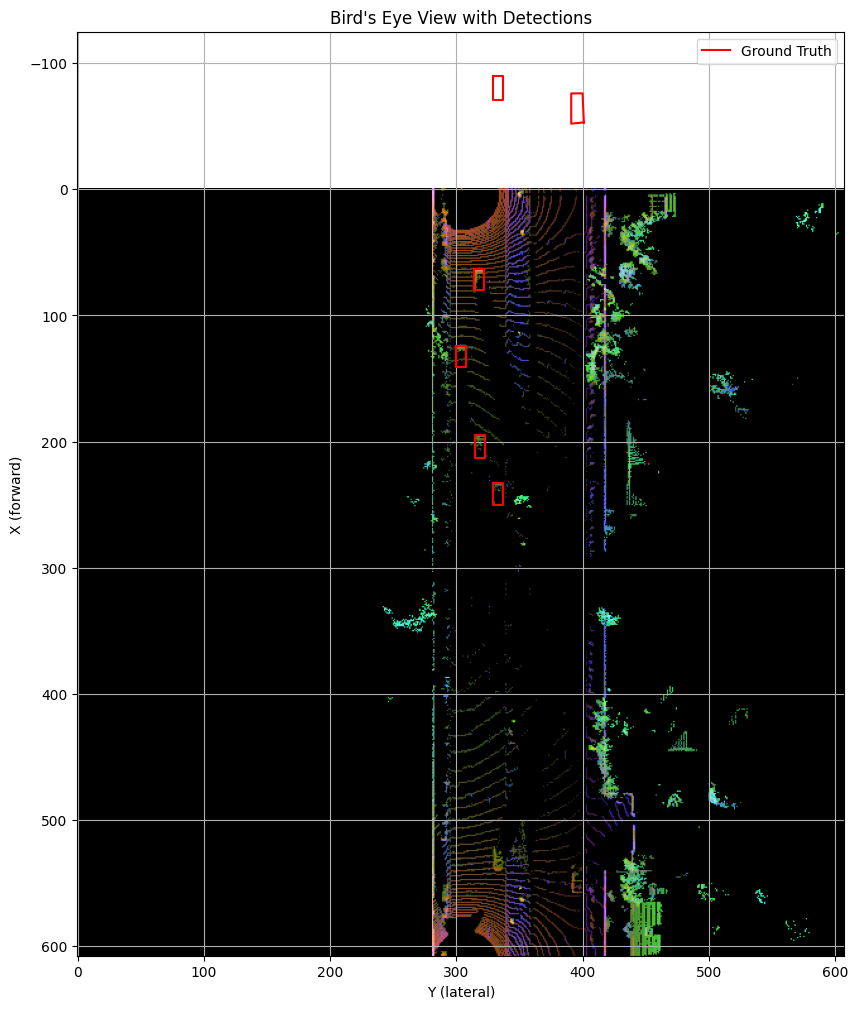

In [157]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_bev_with_detections(bev, predictions=None, ground_truth=None, figsize=(12, 12), config=None):
    """
    Visualize Bird's Eye View (BEV) data with detection boxes overlaid
    
    Args:
        bev: numpy array of shape (channels, height, width)
        predictions: list of prediction dictionaries (optional)
        ground_truth: list of ground truth dictionaries (optional)
        figsize: tuple of figure dimensions
        config: configuration parameters
    """
    plt.figure(figsize=figsize)
    
    # Display BEV map using the same transformation as your visualize_bev function
    bev_map_display = np.transpose(bev, (1, 2, 0))
    plt.imshow(bev_map_display)
    
    # Helper function to convert real-world coordinates to pixel coordinates
    def world_to_pixel(x, y):
        """Convert world coordinates to pixel coordinates based on config limits"""
        x_discretization = (config.lims.x[1] - config.lims.x[0]) / config.bev_height
        y_discretization = (config.lims.y[1] - config.lims.y[0]) / config.bev_width
        
        # Convert x coordinate (forward direction)
        pixel_x = int(x / x_discretization)
        
        # Convert y coordinate (lateral direction)
        # Add width/2 to center the coordinate system
        pixel_y = int(y / y_discretization + config.bev_width / 2)
        
        return pixel_x, pixel_y
    
    # Helper function to draw a rotated rectangle
    def draw_box(pos, scale, rotation, color, linestyle='-', label=None):
        x, y = pos[0], pos[1]  # Forward, left coordinates
        l, w = scale[0], scale[1]  # Length, width
        
        # Create rectangle points (in world coordinates)
        corners = np.array([
            [-l/2, -w/2],
            [l/2, -w/2],
            [l/2, w/2],
            [-l/2, w/2]
        ])
        
        # Rotate corners
        rot_matrix = np.array([
            [np.cos(rotation[2]), -np.sin(rotation[2])],
            [np.sin(rotation[2]), np.cos(rotation[2])]
        ])
        rotated_corners = corners @ rot_matrix.T
        
        # Convert each corner to pixel coordinates
        pixel_corners = []
        for dx, dy in rotated_corners:
            px, py = world_to_pixel(x + dx, y + dy)
            pixel_corners.append([px, py])
        
        # Draw the box
        pixel_corners = np.array(pixel_corners)
        pixel_corners = np.vstack([pixel_corners, pixel_corners[0]])  # Close the rectangle
        plt.plot(pixel_corners[:, 1], pixel_corners[:, 0],  # Note: x and y are swapped for imshow
                color=color, linestyle=linestyle, label=label)
    
    # Draw ground truth boxes
    if ground_truth:
        for gt in ground_truth:
            draw_box(
                gt['pos'], 
                gt['scale'], 
                gt['rot'],
                color='r',
                linestyle='-',
                label='Ground Truth' if gt == ground_truth[0] else None
            )
    
    # Draw prediction boxes
    if predictions:
        for pred in predictions:
            draw_box(
                pred['pos'], 
                pred['scale'], 
                pred['rot'],
                color='r',
                linestyle='--',
                label='Prediction' if pred == predictions[0] else None
            )
    
    plt.title("Bird's Eye View with Detections")
    plt.xlabel("Y (lateral)")
    plt.ylabel("X (forward)")
    
    if predictions or ground_truth:
        plt.legend()
    
    plt.grid(True)
    plt.show()

# Usage example:
pred_detections = convert_predictions_to_lidar_format(predicted_detections)
gt_detections = convert_ground_truth_to_dict(detections)

# Visualize
visualize_bev_with_detections(
    bev.cpu().numpy().squeeze(0),
    predictions=pred_detections,
    ground_truth=gt_detections,
    config=config  # Pass your config
)